# Embedding clustering

Everything so far has used the diagnosis labels directly. This notebook
asks a different question: without looking at the labels at all, do
images that the trained network sees as similar (by the 1280-dimensional
feature vector it computes right before its classification head) actually
group into anything resembling the 7 real diagnostic categories? Comparing
two different clustering algorithms - KMeans and a Gaussian mixture model -
against the labels afterward, purely as an evaluation, not as input to the
clustering itself.

In [1]:
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score, silhouette_score

data = np.load('data/dermamnist_128.npz')
X_test = data['test_images'].astype('float32')
y_test = data['test_labels'].ravel()
class_names = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

model = tf.keras.models.load_model('outputs/transfer_model.keras')
base = [l for l in model.layers if 'mobilenet' in l.name.lower()][0]
gap_layer = [l for l in model.layers if 'global_average_pooling' in l.name][0]

I0000 00:00:1785472835.329479  554222 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785472835.357197  554222 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1785472836.352554  554222 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Embeddings are the 1280-dim pooled feature vector - the same representation the classification head reads from, just stopped one layer earlier.

In [2]:
def extract_embeddings(images, batch_size = 128):
    embeddings = []
    for i in range(0, len(images), batch_size):
        batch = tf.cast(images[i:i + batch_size], tf.float32)
        preprocessed = tf.keras.applications.mobilenet_v2.preprocess_input(batch)
        conv_out = base(preprocessed, training = False)
        pooled = gap_layer(conv_out)
        embeddings.append(pooled.numpy())
    return np.concatenate(embeddings, axis = 0)

embeddings = extract_embeddings(X_test)
embeddings.shape

(2005, 1280)

In [3]:
pca = PCA(n_components = 50, random_state = 42)
embeddings_pca = pca.fit_transform(embeddings)
print(f'50 PCA components explain {pca.explained_variance_ratio_.sum():.1%} of variance')

kmeans = KMeans(n_clusters = 7, n_init = 10, random_state = 42)
kmeans_labels = kmeans.fit_predict(embeddings_pca)

gmm = GaussianMixture(n_components = 7, random_state = 42, n_init = 3)
gmm_labels = gmm.fit_predict(embeddings_pca)

kmeans_labels.shape, gmm_labels.shape

50 PCA components explain 67.1% of variance


((2005,), (2005,))

Comparing both clusterings against the real diagnosis labels - adjusted Rand index (chance-corrected agreement between two groupings, 0 = random, 1 = perfect) and silhouette score (how well-separated the clusters are in embedding space, independent of any label).

In [4]:
results = {
    'kmeans': {
        'ari_vs_true_label': float(adjusted_rand_score(y_test, kmeans_labels)),
        'silhouette': float(silhouette_score(embeddings_pca, kmeans_labels)),
    },
    'gmm': {
        'ari_vs_true_label': float(adjusted_rand_score(y_test, gmm_labels)),
        'silhouette': float(silhouette_score(embeddings_pca, gmm_labels)),
    },
}
pd.DataFrame(results).T

,ari_vs_true_label,silhouette
kmeans,0.028701,0.074829
gmm,0.036617,0.070845


In [5]:
contingency = pd.crosstab(pd.Series(kmeans_labels, name = 'kmeans cluster'),
                           pd.Series(y_test, name = 'true label').map(dict(enumerate(class_names))))
contingency

true label,akiec,bcc,bkl,df,mel,nv,vasc
kmeans cluster,,,,,,,
0,0,1,28,0,62,168,2
1,4,4,12,5,2,269,0
2,1,5,11,0,19,215,2
3,39,36,104,3,49,69,1
4,12,47,49,7,51,215,20
5,8,8,7,5,4,179,3
6,2,2,9,3,36,226,1


For each cluster, the class it contains the most of - if clustering found real structure, several clusters should have one dominant class well above its overall ~1-67% base rate.

In [6]:
purity = contingency.div(contingency.sum(axis = 1), axis = 0)
dominant = purity.idxmax(axis = 1)
dominant_share = purity.max(axis = 1)
pd.DataFrame({'dominant_class': dominant, 'share_of_cluster': dominant_share.round(3),
              'cluster_size': contingency.sum(axis = 1)})

,dominant_class,share_of_cluster,cluster_size
kmeans cluster,,,
0,nv,0.644,261
1,nv,0.909,296
2,nv,0.850,253
3,bkl,0.346,301
4,nv,0.536,401
5,nv,0.836,214
6,nv,0.810,279


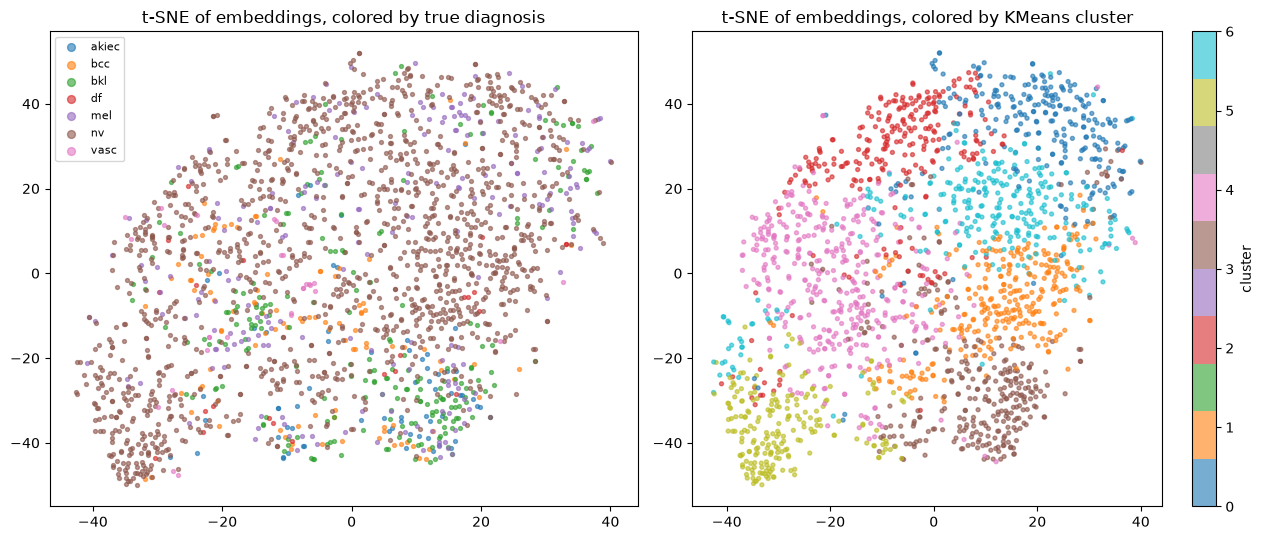

In [7]:
tsne = TSNE(n_components = 2, random_state = 42, perplexity = 30, init = 'pca')
embeddings_2d = tsne.fit_transform(embeddings_pca)

fig, axes = plt.subplots(1, 2, figsize = (13, 5.5))

for i, name in enumerate(class_names):
    mask = y_test == i
    axes[0].scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1], s = 8, label = name, alpha = 0.6)
axes[0].set_title('t-SNE of embeddings, colored by true diagnosis')
axes[0].legend(fontsize = 8, markerscale = 2)

sc = axes[1].scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], s = 8, c = kmeans_labels, cmap = 'tab10', alpha = 0.6)
axes[1].set_title('t-SNE of embeddings, colored by KMeans cluster')
plt.colorbar(sc, ax = axes[1], label = 'cluster')

plt.tight_layout()
plt.savefig('outputs/embedding_clusters.png', dpi = 120)
plt.show()

`nv` dominates the dataset so heavily that it's the easiest structure for any clustering to find by sheer density, even with zero label information - worth checking whether the clusters are doing anything beyond separating `nv` from everything else, or whether they're picking up on genuine sub-structure among the minority classes too.

In [8]:
os.makedirs('outputs', exist_ok = True)
with open('outputs/clustering_results.json', 'w') as f:
    json.dump({
        'kmeans_ari': results['kmeans']['ari_vs_true_label'],
        'gmm_ari': results['gmm']['ari_vs_true_label'],
        'kmeans_silhouette': results['kmeans']['silhouette'],
        'gmm_silhouette': results['gmm']['silhouette'],
        'pca_variance_explained': float(pca.explained_variance_ratio_.sum()),
    }, f, indent = 2)
results

{'kmeans': {'ari_vs_true_label': 0.028700622629616656,
  'silhouette': 0.07482917606830597},
 'gmm': {'ari_vs_true_label': 0.036616690763306516,
  'silhouette': 0.0708446353673935}}